In [6]:
library(tidyverse)
library(broom)

In [7]:
property <- read.csv(
  file = "./data/property_sample_2000.csv"
) |>
  subset(select = c(CURRENT_LAND_VALUE,
    PREVIOUS_LAND_VALUE,
    PREVIOUS_IMPROVEMENT_VALUE,
    YEAR_BUILT
  )) |>
  na.omit()

  property2 <- subset(property,
  is.finite(CURRENT_LAND_VALUE) & CURRENT_LAND_VALUE > 0 &
  is.finite(PREVIOUS_LAND_VALUE) & PREVIOUS_LAND_VALUE > 0 &
  is.finite(PREVIOUS_IMPROVEMENT_VALUE) & PREVIOUS_IMPROVEMENT_VALUE > 0 &
  is.finite(YEAR_BUILT)
)

set.seed(306)



In [8]:
fit <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property)
bb <- coef(fit)

In [9]:
summary(fit)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.48731 -0.05484  0.00512  0.05893  0.54142 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      0.8766076  0.2134483   4.107 4.17e-05 ***
log(PREVIOUS_LAND_VALUE)         0.9843750  0.0030502 322.728  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0049508  0.0026529   1.866 0.062163 .  
YEAR_BUILT                      -0.0003581  0.0001033  -3.466 0.000539 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.1048 on 1996 degrees of freedom
Multiple R-squared:  0.9879,	Adjusted R-squared:  0.9879 
F-statistic: 5.453e+04 on 3 and 1996 DF,  p-value: < 2.2e-16


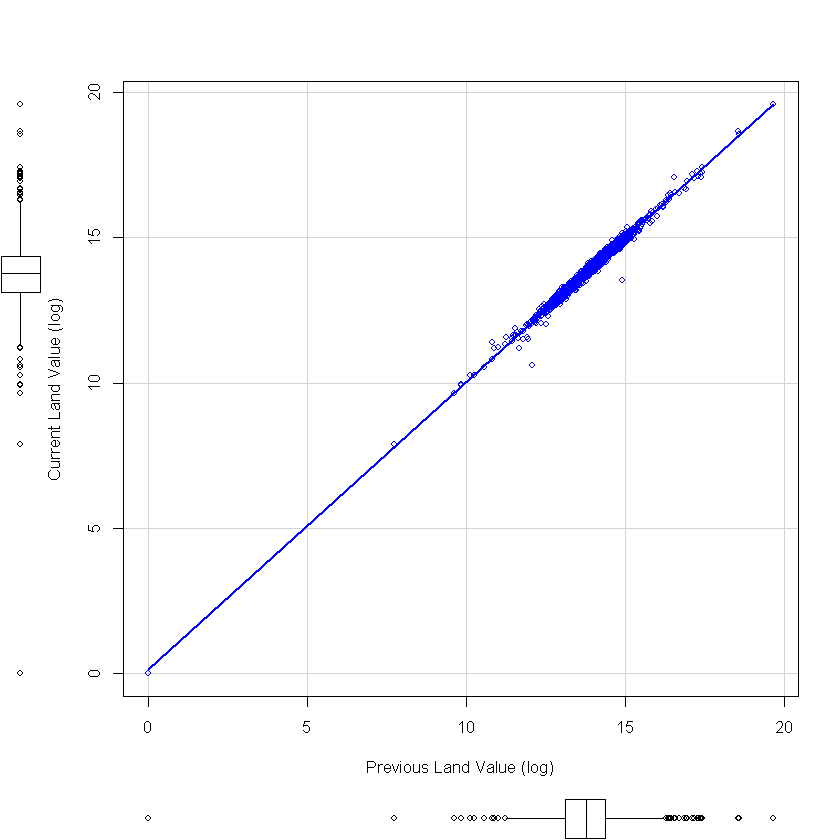

In [10]:
scatterplot(log(property$PREVIOUS_LAND_VALUE), log(property$CURRENT_LAND_VALUE), smooth=FALSE,
            xlab="Previous Land Value (log)", ylab="Current Land Value (log)", legend=c(title="City"))